# Importing libraries 

In [18]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt 
from ultralytics import YOLO
import time 
import os 

# Cars Detection 

In [19]:
model = YOLO("../../Models/yolov8n.pt")
numberPlate = cv2.CascadeClassifier("../../Models/haarcascade_russian_plate_number.xml")

videoPath = ""
cap = cv2.VideoCapture(videoPath)
frame_count = 0 

    
while cap.isOpened():
    ret, frame = cap.read()
    if not ret :
        break
    frame_count += 1
    results = model(frame)
    for result in results[0].boxes:
        cls = int(result.cls[0])
        if cls == 2:
            x1, y1, x2, y2 = map(int, result.xyxy[0])
            car_image = frame[y1:y2, x1:x2]
            getPlate(car_image)
            
            annotated_frame = results[0].plot()
            cv2.imshow("car and plate Detection", annotated_frame)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
cap.release()
cv2.destroyAllWindows( )

# Get plate from a car 

In [20]:
def getPlate(img):
    imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    numberPlates = numberPlate.detectMultiScale(imgGray,1.1 , 10)
    imgRoi = None
    for (x, y, w, h) in numberPlates:
        cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,255), 2)
        cv2.putText(img, "number plate",(x,y-5), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1,color,2)
        plate_image = img[y:y+h, x:x+w]
        timestamp = int(time.time() * 1000)  # Unique timestamp
        plate_filename = f'/plate_{frame_count}_{timestamp}.jpg'
        cv2.imwrite(plate_filename, plate_image)
        print(f"Saved plate: {plate_filename}")
        plt.subplot(1,2,1)
        plt.imshow(imgRoi)
    plt.subplot(1,2,2)
    plt.imshow(img)


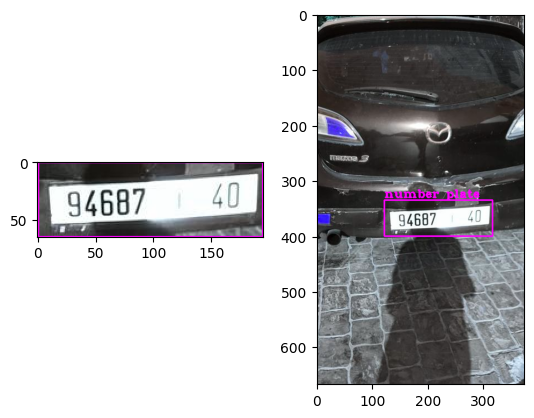

In [15]:
import cv2

frameWidth = 300
frameHeight = 300
numberPlate = cv2.CascadeClassifier("../../Models/haarcascade_russian_plate_number.xml")
minArea  = 200
color = (255,0,255)


img = cv2.imread("../../Dataset/car3.jpg")
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
numberPlates = numberPlate.detectMultiScale(imgGray,1.1 , 10)
imgRoi = None
for (x, y, w, h) in numberPlates:
    area = w*h
    if area > minArea:
        cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,255), 2)
        cv2.putText(img, "number plate",(x,y-5), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1,color,2)
        imgRoi = img[y:y+h, x:x+w]
        plt.subplot(1,2,1)
        plt.imshow(imgRoi)
plt.subplot(1,2,2)
plt.imshow(img)

if cv2.waitKey(0) & 0xFF == ord('s'):
    cv2.imwrite("Noplate_"+str(count)+".jpg", imgRoi)
    cv2.rectangle(img, (0,200), (640, 265), (0,0,255), cv2.FILLED)
    cv2.putText(img, "scan saved", (150,265), cv2.FONT_HERSHEY_DUPLEX,2,(0,0,255), 2)
    plt.imshow(img)
    cv2.waitKey(500)
    count +=1



In [17]:
import ultralytics 